In [2]:
!pip install -q gdown tensorflow matplotlib

In [3]:
import gdown

file_id = "1219EeGE1XTJVXYaulynJSa3BXGsbNCLx"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "pneumonia.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=1c8beb70-9420-4263-aa88-6a5146995161
To: /content/pneumonia.zip
100%|██████████| 1.23G/1.23G [00:24<00:00, 49.4MB/s]


'pneumonia.zip'

In [4]:
import zipfile
import os

with zipfile.ZipFile("pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("Unzipped successfully!")

Unzipped successfully!


In [5]:
base_path = "/content/data"

# Auto-detect correct root
for root, dirs, files in os.walk(base_path):
    if 'train' in dirs and 'test' in dirs:
        data_dir = root
        break

print("Dataset path:", data_dir)

Dataset path: /content/data


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_data = val_test_gen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = val_test_gen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [7]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,846,977 (7.05 MB)

 Trainable params: 1,846,977 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    verbose=1
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 433ms/step - accuracy: 0.8125 - loss: 0.4391 - val_accuracy: 0.8750 - val_loss: 0.3791
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 418ms/step - accuracy: 0.9097 - loss: 0.2298 - val_accuracy: 0.6250 - val_loss: 1.0482
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 421ms/step - accuracy: 0.9266 - loss: 0.1883 - val_accuracy: 0.7500 - val_loss: 0.6289
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 419ms/step - accuracy: 0.9438 - loss: 0.1608 - val_accuracy: 0.7500 - val_loss: 0.3700
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 424ms/step - accuracy: 0.9427 - loss: 0.1614 - val_accuracy: 0.6250 - val_loss: 0.6990
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 417ms/step - accuracy: 0.9450 - loss: 0.1422 - val_accuracy: 0.6875 - val_loss: 1.0258
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 423ms/step - accuracy: 0.9452 - loss: 0.1407 - val_accuracy: 0.6250 - val_loss: 0.6363
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 418ms/step - accuracy: 0.9507 - loss: 0

In [9]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.8718 - loss: 0.4773
Test Accuracy: 0.8717948794364929


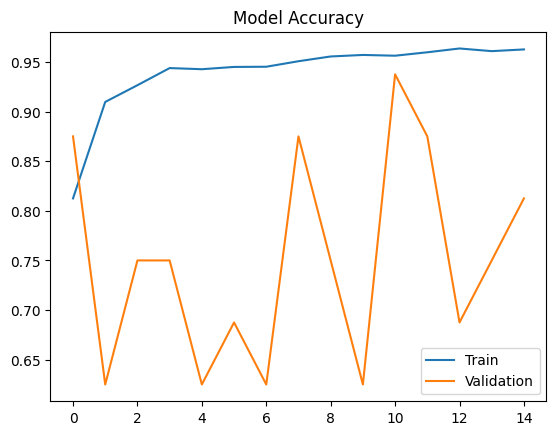

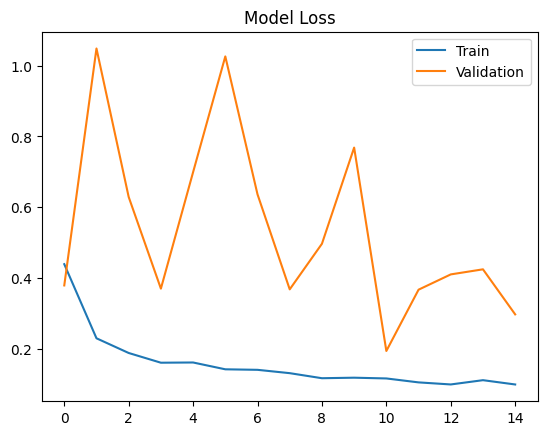

In [10]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train','Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train','Validation'])
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 398ms/step


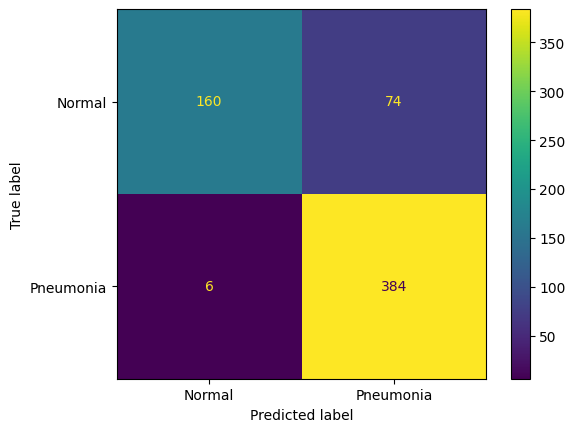

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(test_data.classes, y_pred)

ConfusionMatrixDisplay(cm, display_labels=["Normal","Pneumonia"]).plot()
plt.show()